# **영화 데이터 탐색적 분석**

이 코드를 보기 위해서는 우리 분석의 전제를 알고 가야합니다.

우리는 평점과 인기도 두 점수를 분석에 활용했음.
평점은 관객의 만족도로서 작품의 완성도 및 팬덤의 점수로 생각하고 분석을 진행했습니다.

인기도는 트렌드성입니다. 사람들이 그 시기에 관심을 얼마나 가지며, 많이 대중에게 노출되는 정도이므로, 트렌드와 관련된 지표로 생각했습니다.

해당 분석을 위해 두 지표를 다음과 같이 전제하였습니다.

## **1. 데이터 불러오기 및 기본적인 탐색**

In [2]:
import pandas as pd

movie = pd.read_csv('movie.csv')
movie.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1609 entries, 0 to 1608
Data columns (total 15 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   title            1609 non-null   object 
 1   genres           1609 non-null   object 
 2   overview         1609 non-null   object 
 3   keywords         1568 non-null   object 
 4   director         1609 non-null   object 
 5   cast             1600 non-null   object 
 6   runtime          1609 non-null   int64  
 7   popularity       1609 non-null   float64
 8   vote_average     1609 non-null   float64
 9   vote_count       1609 non-null   int64  
 10  release_date     1609 non-null   object 
 11  poster_url       1609 non-null   object 
 12  movie_id         1609 non-null   int64  
 13  poster_mood_kor  1609 non-null   object 
 14  poster_mood_eng  1609 non-null   object 
dtypes: float64(2), int64(3), object(10)
memory usage: 188.7+ KB


### 1.1 런타임 분석

In [4]:
print("\n--- 런타임 기술 통계량 ---")
print(movie['runtime'].describe())
# 평균적으로 115분의 영화임. 최솟값이 0시간인 것도 있음.


--- 런타임 기술 통계량 ---
count    1609.000000
mean      115.774394
std        31.202966
min         0.000000
25%        99.000000
50%       114.000000
75%       130.000000
max       432.000000
Name: runtime, dtype: float64


In [12]:
extreme_short = movie[movie['runtime'] < 30][['title', 'runtime']]
extreme_long = movie[movie['runtime'] > 240][['title', 'runtime']]

print(f"\n30분 미만 영화 개수: {len(extreme_short)}")
print(f"240분 초과 영화 개수: {len(extreme_long)}")


30분 미만 영화 개수: 26
240분 초과 영화 개수: 5


W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)


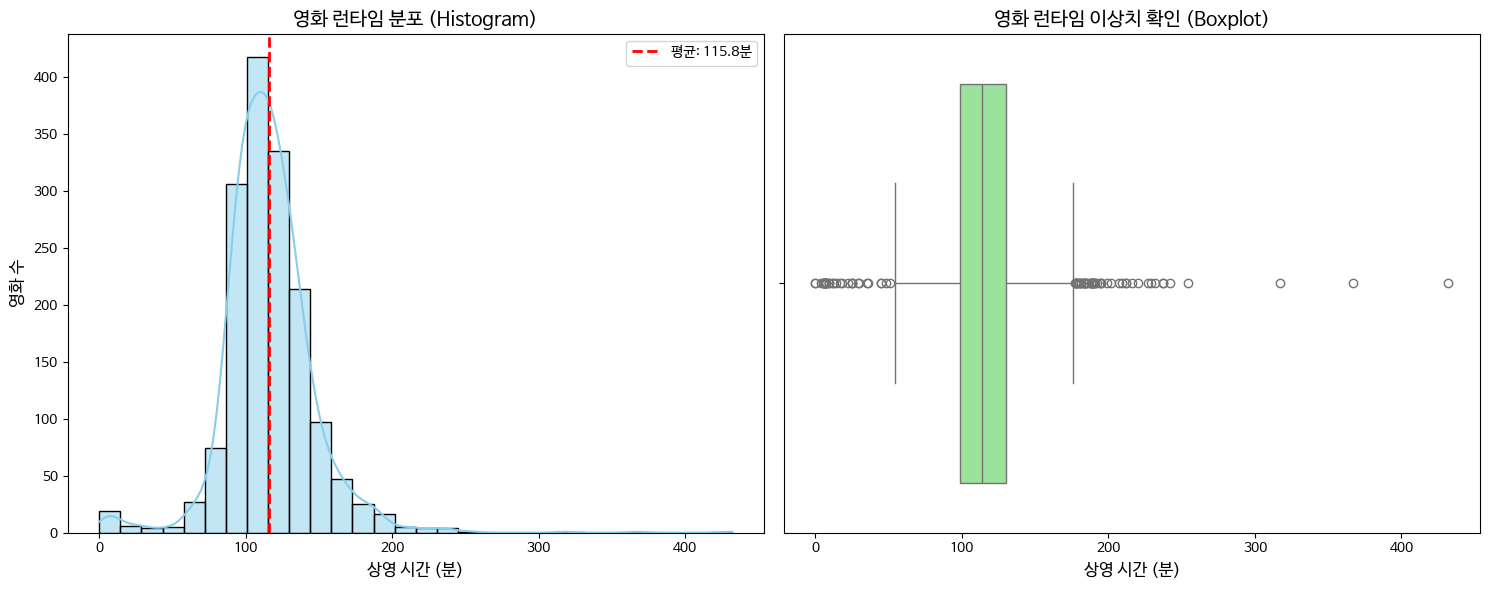

In [21]:
# 1. 한글 폰트 설치 및 폰트 캐시 리빌드 (코랩 환경용)
!apt-get update -qq
!apt-get install fonts-nanum -qq

import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import seaborn as sns
import warnings

# 모든 경고 메시지 무시 설정 (런타임 분석 시 발생하는 자잘한 경고 방지)
warnings.filterwarnings('ignore')

# 2. 설치된 나눔 폰트를 matplotlib 폰트 매니저에 등록
# 아래 코드가 있어야 새로 설치한 폰트를 파이썬이 인식합니다.
fm.fontManager.addfont('/usr/share/fonts/truetype/nanum/NanumBarunGothic.ttf')
plt.rc('font', family='NanumBarunGothic')
plt.rcParams['axes.unicode_minus'] = False

# 3. 데이터 시각화 진행 (데이터프레임 이름을 movie로 맞춰두셨네요!)
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(15, 6))

# [왼쪽 그래프] 히스토그램 (Histogram)
sns.histplot(data=movie, x='runtime', bins=30, kde=True, ax=axes[0], color='skyblue')
axes[0].set_title('영화 런타임 분포 (Histogram)', fontsize=14)
axes[0].set_xlabel('상영 시간 (분)', fontsize=12)
axes[0].set_ylabel('영화 수', fontsize=12)

# 평균값 계산 및 점선 표시
runtime_mean = movie['runtime'].mean()
axes[0].axvline(runtime_mean, color='red', linestyle='--', linewidth=2, label=f"평균: {runtime_mean:.1f}분")
axes[0].legend()

# [오른쪽 그래프] 박스플롯 (Boxplot)
sns.boxplot(data=movie, x='runtime', ax=axes[1], color='lightgreen')
axes[1].set_title('영화 런타임 이상치 확인 (Boxplot)', fontsize=14)
axes[1].set_xlabel('상영 시간 (분)', fontsize=12)

# 그래프 레이아웃 정렬 및 출력
plt.tight_layout()
plt.show()

In [22]:
movie[movie['runtime']<5]

,title,genres,overview,keywords,director,cast,runtime,popularity,vote_average,vote_count,release_date,poster_url,movie_id,poster_mood_kor,poster_mood_eng
95,오디세이,"판타지, 액션",현시대 영화계 최고의 거장 크리스토퍼 놀란 감독 최초의 시대극. 영화 전편을 IMA...,"greek mythology, based on song, poem or rhyme,...",크리스토퍼 놀란,"맷 데이먼, 톰 홀랜드, 앤 해서웨이",0,31.6600,0.000,0,2026-07-15,https://image.tmdb.org/t/p/w500/8ze9OcVuFiy94s...,1368337,웅장한 대서사시,epic and grand
1333,신극장판 은혼: 요시와라 대염상,"액션, SF/미래","해결사 사무소를 운영하는 ‘사카타 긴토키’. 어느 날, 그는 소매치기로 생계를 이어...","samurai, based on manga, shounen, anime",安藤尚也,"스기타 토모카즈, 사카구치 다이스케, 쿠기미야 리에",0,2.5506,0.000,0,2026-02-13,https://image.tmdb.org/t/p/w500/mVtUatYLMj30v8...,1530941,밝고 유쾌한 분위기,bright and feel-good
1523,제리의 게임,"코미디/힐링, 드라마/성장",혼자서 체스를 하는 노인의 이야기를 묘사한 픽사 스튜디오의 단편 애니메이션. 스스로...,"chess, eyeglasses, park, false teeth, dentures",Jan Pinkava,밥 피터슨,4,1.3328,7.629,1216,1997-11-24,https://image.tmdb.org/t/p/w500/8PdCk3T9EkcKni...,13929,웅장한 대서사시,epic and grand


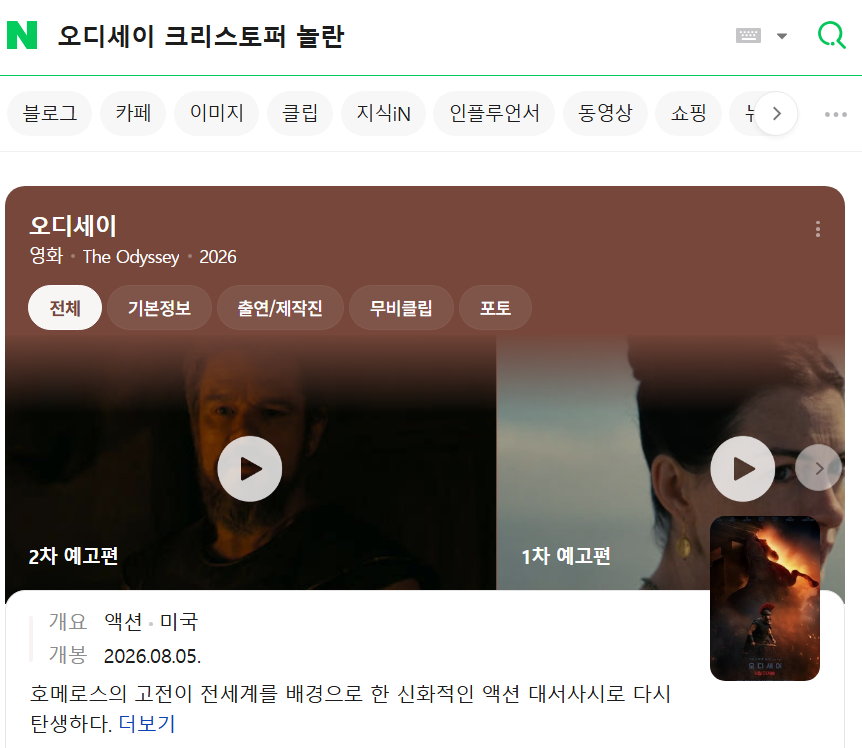

작품을 살펴보니 runtime이 0인 영화는 아직 개봉을 하지 않은 영화였습니다.
우리 서비스의 목적은 추천 시스템 구축으로, 미개봉 영화를 추천해주는 것은 추천의 의미가 퇴색되는것 같아, 데이터에서 제외했습니다.

In [23]:
movie = movie[movie['runtime']!=0]
movie.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1607 entries, 0 to 1608
Data columns (total 15 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   title            1607 non-null   object 
 1   genres           1607 non-null   object 
 2   overview         1607 non-null   object 
 3   keywords         1566 non-null   object 
 4   director         1607 non-null   object 
 5   cast             1598 non-null   object 
 6   runtime          1607 non-null   int64  
 7   popularity       1607 non-null   float64
 8   vote_average     1607 non-null   float64
 9   vote_count       1607 non-null   int64  
 10  release_date     1607 non-null   object 
 11  poster_url       1607 non-null   object 
 12  movie_id         1607 non-null   int64  
 13  poster_mood_kor  1607 non-null   object 
 14  poster_mood_eng  1607 non-null   object 
dtypes: float64(2), int64(3), object(10)
memory usage: 200.9+ KB


### 1.2 결측값 분석

In [24]:
movie[movie['cast'].isna()]

,title,genres,overview,keywords,director,cast,runtime,popularity,vote_average,vote_count,release_date,poster_url,movie_id,poster_mood_kor,poster_mood_eng
362,플로우,"판타지, 액션","인간이 살았던 흔적만이 남아있는 세상, 홀로 집을 지키던 '고양이'는 갑작스러운 대...","ocean, cat, boat, dystopia, survival",긴츠 질발로디스,NaN,85,15.3767,8.088,2806,2024-08-29,https://image.tmdb.org/t/p/w500/iEDrRE5TWjKrWO...,823219,웅장한 대서사시,epic and grand
1350,파이퍼,"코미디/힐링, 드라마/성장",배고픈 도요새가 엄마의 도움 없이 먹이를 찾아 나선다는 이야기.,"fear, anxious, playful, short film, assertive",Alan Barillaro,NaN,6,2.4325,8.148,1731,2016-06-16,https://image.tmdb.org/t/p/w500/m73Z8wm9H4UOa0...,399106,어두운 시네마틱 느와르,dark and cinematic noir
1518,혹시 내게 무슨 일이 생기면,드라마/성장,학교에서 누군가 총을 쏘았다. 아이가 희생됐다. 남겨진 부모의 나날. 공허한 시간은...,"tearjerker, social issues, grieving parents, l...",Michael Govier,NaN,12,1.3647,7.685,989,2020-03-07,https://image.tmdb.org/t/p/w500/85tDhACvKDQxQo...,713776,공포스럽고 기괴한,horror and eerie
1520,킷불,"코미디/힐링, 드라마/성장","매우 독립적인 길고양이와 핏불, 두 동물 사이에 예상치 못한 친밀감이 싹튼다. 함께...","friendship, cat, dog, animals, short film",Rosana Sullivan,NaN,9,1.3494,7.947,398,2019-01-18,https://image.tmdb.org/t/p/w500/kukmYNBxQXFfew...,574074,어두운 시네마틱 느와르,dark and cinematic noir
1525,나무 저 너머엔,"코미디/힐링, 드라마/성장",호기심 많은 새끼를 안전하게 보호하려는 부모 너구리의 사랑을 다룬 애니메이션,short film,Natalie Nourigat,NaN,7,1.3271,8.100,388,2021-11-24,https://image.tmdb.org/t/p/w500/rz4trwLDm7SyVH...,831827,웅장한 대서사시,epic and grand
1544,어스 어게인,"로맨스, 코미디/힐링","리듬과 움직임으로 진동하는 활기찬 도시를 배경으로, 한 노인과 마음이 젊은 그의 아...","new york city, dancing, rain, musical, lovers",Zach Parrish,NaN,7,1.2191,7.810,348,2021-03-03,https://image.tmdb.org/t/p/w500/zKnenwvQB6xA4m...,779047,웅장한 대서사시,epic and grand
1583,퀸 락 몬트리올,음악/스포츠,"'보헤미안 랩소디'부터 '위 윌 락 유', '위 아더 챔피온스'까지, 1981년 1...",concert,Saul Swimmer,NaN,96,0.6203,8.100,10,2024-01-18,https://image.tmdb.org/t/p/w500/ynnYU19czD7giz...,1534626,빈티지한 향수,vintage and nostalgic
1602,극장판 반짝반짝 달님이: 싱어롱 파티,"판타지, 액션",상상력 가득한 6살 공감소녀 달님이의 환상 속 어드벤처! 동화책 속으로 들어가 백설...,NaN,Lee Byeong-jik,NaN,70,0.1061,0.000,0,2026-05-01,https://image.tmdb.org/t/p/w500/vKS6arCPL0rMLe...,1660316,빈티지한 향수,vintage and nostalgic
1606,그림자 내각,드라마/성장,"1979년 10월 16일, 유신정권을 종식한 부마 민주항쟁에서부터 시작하여 10.2...",2024 south korean martial law,Kim Si-woo,NaN,99,0.0338,0.000,0,2026-05-14,https://image.tmdb.org/t/p/w500/1HXPRXq1app922...,1667233,웅장한 대서사시,epic and grand


검색 결과 다른 작품들은 대사가 없는 작품이라 '없음'이라 표시했지만,
영화 파이퍼는 데이터가 아예 잘못된 것이기에 삭제

In [25]:
movie = movie[movie['title'].str.strip() != '파이퍼'].reset_index(drop=True)
print(f"'파이퍼' 제거 후 데이터 행 개수: {len(movie)}개")

movie['cast'] = movie['cast'].fillna('없음')

print("cast 컬럼의 남은 결측치 개수:", movie['cast'].isnull().sum())

'파이퍼' 제거 후 데이터 행 개수: 1606개
cast 컬럼의 남은 결측치 개수: 0


### 키워드 결측치

In [29]:
print(movie[movie['keywords'].isnull()][['title', 'genres']].head(10))

                      title       genres
40   마이클 잭슨: 더 라이프 오브 언 아이콘       음악/스포츠
202                    헌팅시즌   액션, 스릴러/범죄
212                  버려진 청춘          로맨스
230              타부: 가족의 비밀  로맨스, 스릴러/범죄
455                  인필트레이트   액션, 스릴러/범죄
503                    어웨이크       스릴러/범죄
517      마이클 잭슨 스: 맨 인 더 미러       드라마/성장
653                   빅 브라더   액션, 코미디/힐링
706               말괄량이 길들이기       드라마/성장
742                    요재연담   판타지, 공포/호러


In [34]:
movie['keywords']

,keywords
0,"journalist, egypt, monster, ritual, kidnapping"
1,"post-traumatic stress disorder (ptsd), gun, an..."
2,"friendship, coma, based on novel or book, brav..."
3,"galaxy, friendship, sibling relationship, spac..."
4,"based on tv series, suspense"
...,...
1601,biography
1602,NaN
1603,2024 south korean martial law
1604,"sibling relationship, hunger, world war ii, wa..."


In [35]:
movie['overview']

,overview
0,"한 기자의 어린 딸이 흔적도 없이 사막으로 사라진다. 그리고 8년 후, 산산이 부서..."
1,복수 이상의 의미를 찾아 헤매던 프랭크 캐슬은 뜻밖의 싸움을 다시 시작하게 된다.
2,눈을 떠보니 아득한 우주의 한가운데에서 깨어난 중학교 과학교사 그레이스는 희미한 기...
3,브루클린의 배관공에서 세계를 구한 히어로로 레벨업한 형제 ‘마리오’와 ‘루이지’는 ...
4,잭 라이언은 국제 비밀 작전으로 치명적인 음모의 실체가 드러나면서 마지못해 다시 첩...
...,...
1601,"예술가, 남자, 연인, 무정부주의자, 이방인, 혁명가... 파블로 피카소 서거 50..."
1602,"메이저 데뷔 10주년, 그 눈부신 성공 뒤에 숨겨진 밴드의 ‘기원(ORIGIN)’을..."
1603,"1979년 10월 16일, 유신정권을 종식한 부마 민주항쟁에서부터 시작하여 10.2..."
1604,"2차 세계대전, 일본의 한 마을에 폭격기로 인한 대공습이 일어난다. 마을이 화염으로..."


In [36]:
!pip install konlpy -qq

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 19.4/19.4 MB 81.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 438.5/438.5 kB 30.7 MB/s eta 0:00:00


In [37]:
import pandas as pd
from konlpy.tag import Okt
from collections import Counter

# 형태소 분석기 초기화
okt = Okt()

# 2. 줄거리(overview)에서 핵심 명사(키워드)를 추출하는 함수 정의
def extract_keywords_from_overview(text, num_keywords=3):
    if pd.isna(text) or text.strip() == '':
        return ''

    # 명사만 추출
    nouns = okt.nouns(text)

    # 의미 없는 단어(불용어) 제거 (필요에 따라 추가 가능)
    stopwords = ['영화', '작품', '이야기', '시작', '그', '그녀', '그들', '나', '우리', '대한', '위해', '통해']
    meaningful_nouns = [noun for noun in nouns if noun not in stopwords and len(noun) > 1]

    # 가장 자주 등장하는 명사 상위 N개 추출
    most_common = Counter(meaningful_nouns).most_common(num_keywords)

    # 단어들만 콤마(,)로 연결하여 반환
    keywords_list = [word for word, count in most_common]
    return ', '.join(keywords_list)

# 3. 테스트 및 적용을 위해 결측치가 있는 행의 인덱스 미리 확보
# (나중에 잘 채워졌는지 확인하기 위함)
null_keywords_idx = movie[movie['keywords'].isnull()].index

print(f"현재 keywords 결측치 개수: {len(null_keywords_idx)}개")

# 4. 결측치 채우기 로직 실행
for idx in null_keywords_idx:
    row = movie.loc[idx]

    # 1) 줄거리에서 핵심 단어 추출
    extracted_words = extract_keywords_from_overview(row['overview'], num_keywords=3)

    # 2) 해당 영화의 장르 가져오기
    genre_words = row['genres'] if pd.notna(row['genres']) else ''

    # 3) 장르와 추출된 키워드 합치기
    if extracted_words and genre_words:
        combined_keywords = f"{genre_words}, {extracted_words}"
    else:
        combined_keywords = genre_words or extracted_words # 둘 중 하나만 있는 경우 처리

    # 4) 데이터프레임에 적용
    movie.at[idx, 'keywords'] = combined_keywords

# 5. 결과 검증
print("\n--- 결측치 처리 후 남은 개수 ---")
print("keywords 결측치 개수:", movie['keywords'].isnull().sum())

print("\n--- 실제로 채워진 데이터 예시 (상위 5개) ---")
# 아까 결측치였던 행들을 다시 뽑아서 확인
print(movie.loc[null_keywords_idx, ['title', 'genres', 'overview', 'keywords']].head(5))

현재 keywords 결측치 개수: 41개

--- 결측치 처리 후 남은 개수 ---
keywords 결측치 개수: 0

--- 실제로 채워진 데이터 예시 (상위 5개) ---
                      title       genres  \
40   마이클 잭슨: 더 라이프 오브 언 아이콘       음악/스포츠   
202                    헌팅시즌   액션, 스릴러/범죄   
212                  버려진 청춘          로맨스   
230              타부: 가족의 비밀  로맨스, 스릴러/범죄   
455                  인필트레이트   액션, 스릴러/범죄   

                                              overview  \
40   은 최초 공개되는 마이클 잭슨의 생전, 그를 가장 가까이에서 지켜보았던 이들의 인터...   
202  은둔하며 살아가던 생존 전문가와 그의 딸은 강가에서 상처 입은 정체불명의 여자를 구...   
212  약착같이 돈을 벌어 잘살아 보려고 가출한 명자는 공장의 남자에게 몸을 뺏기고 버림받...   
230  유럽에서 활동하는 사진작가 '타일러'는 오랜만에 아빠와 새엄마가 살고 있는 미국 집...   
455  범죄가 만연한 도시에서, 정부 요원 릴리 첸은 남편이 납치되자 의무와 가족 사이에서...   

                      keywords  
40         음악/스포츠, 잭슨, 마이클, 공개  
202    액션, 스릴러/범죄, 은둔, 생존, 전문가  
212            로맨스, 명자, 사장, 회장  
230  로맨스, 스릴러/범죄, 타일러, 새엄마, 아빠  
455     액션, 스릴러/범죄, 범죄, 릴리, 남편  


In [42]:
# 기존 에러가 나던 코드: from deep-translator import GoogleTranslator
# 수정된 코드:
!pip install deep-translator -qq

from deep_translator import GoogleTranslator  # '-'를 '_'로 변경!
import pandas as pd
import time
import re

# 번역기 인스턴스 생성 (한글 -> 영어)
translator = GoogleTranslator(source='ko', target='en')

# 안전한 번역 함수 정의
def translate_to_en(text):
    if pd.isna(text) or text.strip() == '':
        return ''
    try:
        translated = translator.translate(text)
        return translated.lower().strip()
    except Exception as e:
        print(f"번역 에러 발생: {e}")
        return ''

# 한글 포함 여부 확인 함수
def contains_hangul(text):
    if pd.isna(text): return False
    return bool(re.search('[ㄱ-ㅎㅏ-ㅣ가-힣]', str(text)))

# keywords 컬럼에 한글이 섞여있는 인덱스 추출
korean_keywords_idx = movie[movie['keywords'].apply(contains_hangul)].index
print(f"영어 변환 대상 영화 개수: {len(korean_keywords_idx)}개")

# 한글 키워드를 영어로 번역하여 덮어쓰기
print("\n--- 영어 번역 및 데이터 적용 시작 ---")
for idx in korean_keywords_idx:
    current_keywords = movie.loc[idx, 'keywords']

    word_list = [w.strip() for w in current_keywords.split(',') if w.strip()]

    translated_words = []
    for word in word_list:
        if contains_hangul(word):
            en_word = translate_to_en(word)
            if en_word:
                translated_words.append(en_word)
        else:
            translated_words.append(word.lower())

    movie.at[idx, 'keywords'] = ', '.join(translated_words)
    time.sleep(0.2)

print("✔ 모든 키워드가 영어로 변환되었습니다.")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.3/42.3 kB 2.6 MB/s eta 0:00:00
영어 변환 대상 영화 개수: 41개

--- 영어 번역 및 데이터 적용 시작 ---
✔ 모든 키워드가 영어로 변환되었습니다.


### 1.3 인기도 및 평점 분석

In [43]:
correlation_pop_vote = movie['vote_average'].corr(movie['popularity'])
correlation_count_vote = movie['vote_average'].corr(movie['vote_count'])

print(f"평점과 인기도의 상관계수: {correlation_pop_vote:.2f}")
print(f"평점과 투표 수의 상관계수: {correlation_count_vote:.2f}")

평점과 인기도의 상관계수: -0.00
평점과 투표 수의 상관계수: 0.16


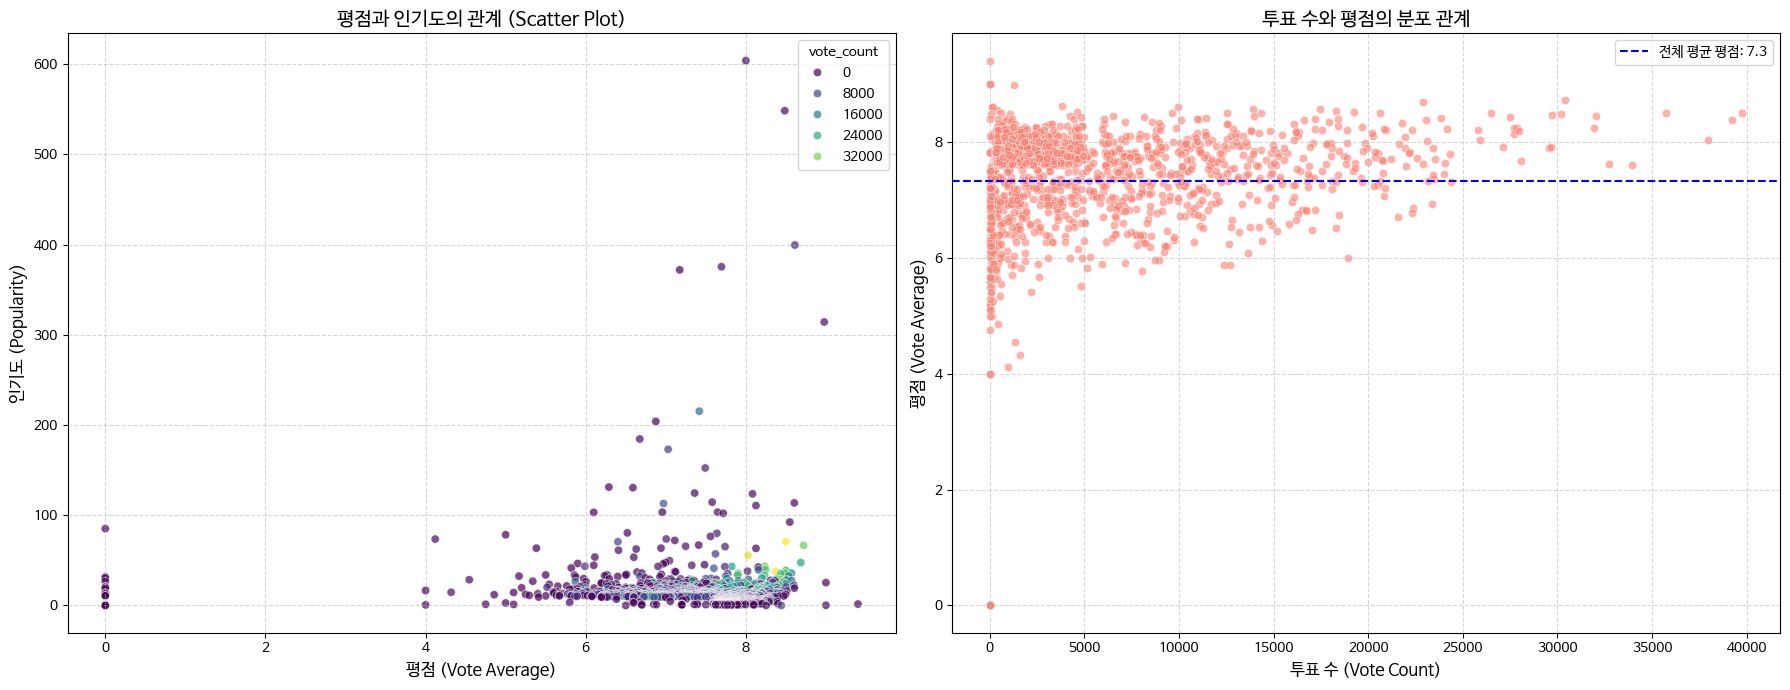

In [44]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# 그래프 도화지 크기 설정 (1행 2열)
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(18, 7))

# ----------------------------------------------------
# [왼쪽 그래프] 평점(vote_average) vs 인기도(popularity)
# ----------------------------------------------------
# 투표 수(vote_count)의 많고 적음을 점의 색상(hue)으로 표현
sns.scatterplot(
    data=movie,
    x='vote_average',
    y='popularity',
    hue='vote_count',
    palette='viridis',
    alpha=0.7,
    ax=axes[0]
)
axes[0].set_title('평점과 인기도의 관계 (Scatter Plot)', fontsize=14, fontweight='bold')
axes[0].set_xlabel('평점 (Vote Average)', fontsize=12)
axes[0].set_ylabel('인기도 (Popularity)', fontsize=12)
axes[0].grid(True, linestyle='--', alpha=0.5)

# ----------------------------------------------------
# [오른쪽 그래프] 투표 수(vote_count) vs 평점(vote_average)
# ----------------------------------------------------
# 투표 수가 적은 영화들이 평점 극단값(0점 혹은 10점 등)을 갖는지 확인
sns.scatterplot(
    data=movie,
    x='vote_count',
    y='vote_average',
    color='salmon',
    alpha=0.6,
    ax=axes[1]
)

axes[1].axhline(movie['vote_average'].mean(), color='blue', linestyle='--', linewidth=1.5, label=f"전체 평균 평점: {movie['vote_average'].mean():.1f}")
axes[1].set_title('투표 수와 평점의 분포 관계', fontsize=14, fontweight='bold')
axes[1].set_xlabel('투표 수 (Vote Count)', fontsize=12)
axes[1].set_ylabel('평점 (Vote Average)', fontsize=12)
axes[1].legend()
axes[1].grid(True, linestyle='--', alpha=0.5)

# 레이아웃 정돈 후 출력
plt.tight_layout()
plt.show()

딱히 유의미한 상관관계는 발견하지 못했다. 그러나 vote_count가 높아질수록
평점이 어느정도 올라가는 분포를 확인했다. 물론 상관관계에서는 적은 통계를 보인다.(0.16이면 거의 없는 수준)


그러나 실제로 그래프를 그려보니, 대게 많은 영화가 vote count가 낮아, 상관 분석을 흐리고 있다. 당연히 잘 된 영화가 적으나, 데이터의 불균형이다.
vote_count가 대략 150000 이상부터 관객의 평점이 좋아지는 것을 알 수 있다.

 결론적으로 vote_count가 낮은 영화는 신뢰도가 낮아, 추천 로직에 활용할 수 있을 것 같다.

## 2.시계열 및 트렌드 분석

### 2.1 개봉일 분석

In [46]:
movie['release_date_clean'] = pd.to_datetime(movie['release_date'], errors='coerce')

print("날짜 변환 후 결측치 개수:", movie['release_date_clean'].isnull().sum())

날짜 변환 후 결측치 개수: 0


In [47]:
movie_time = movie.dropna(subset=['release_date_clean']).copy()

movie_time['release_year'] = movie_time['release_date_clean'].dt.year
movie_time['release_month'] = movie_time['release_date_clean'].dt.month

weekday_map = {0: '월', 1: '화', 2: '수', 3: '목', 4: '금', 5: '토', 6: '일'}
movie_time['release_weekday'] = movie_time['release_date_clean'].dt.dayofweek.map(weekday_map)

print(movie_time[['title', 'release_date', 'release_year', 'release_month', 'release_weekday']].head())

                 title release_date  release_year  release_month  \
0           리 크로닌의 미이라   2026-04-15          2026              4   
1          퍼니셔 원 라스트 킬   2026-05-12          2026              5   
2            프로젝트 헤일메리   2026-03-15          2026              3   
3           슈퍼 마리오 갤럭시   2026-04-01          2026              4   
4  톰 클랜시의 잭 라이언: 고스트 워   2026-05-20          2026              5   

  release_weekday  
0               수  
1               화  
2               일  
3               수  
4               수  


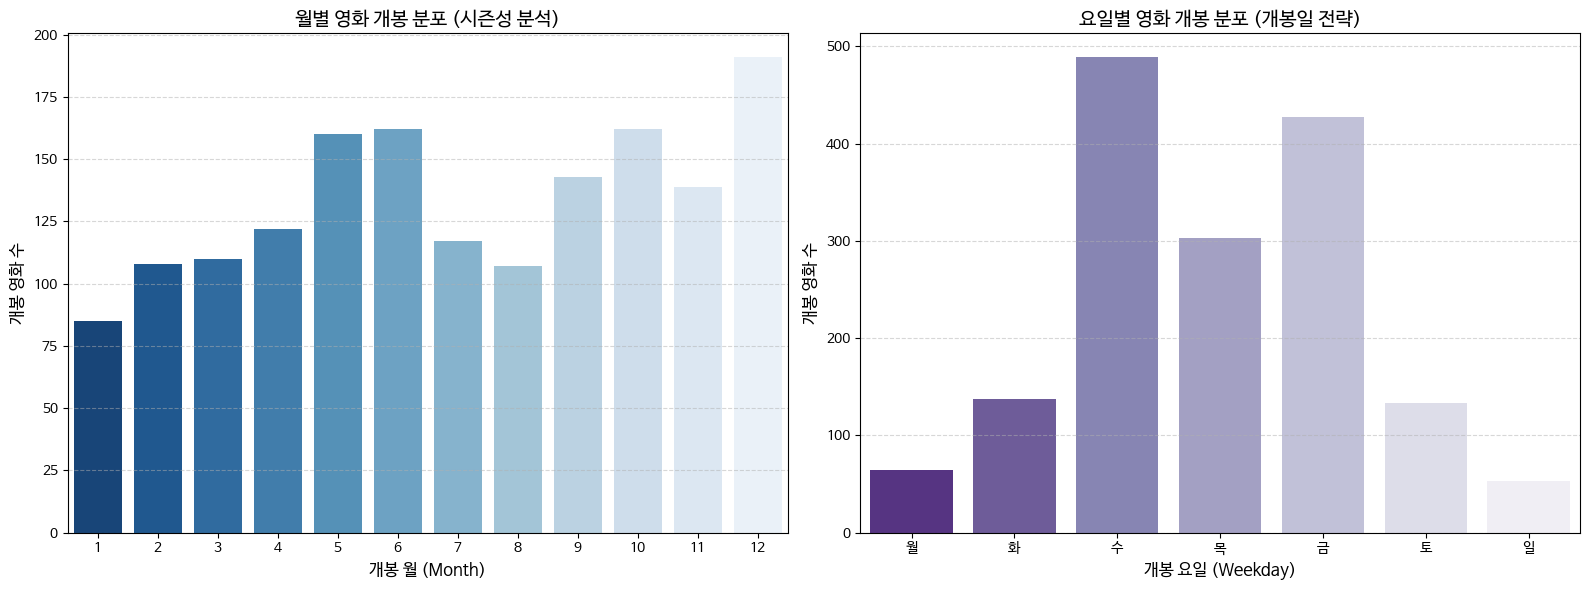

In [48]:
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(16, 6))

# [왼쪽 그래프] 월별 영화 개봉 건수 (시즌성 분석)
sns.countplot(
    data=movie_time,
    x='release_month',
    palette='Blues_r',
    ax=axes[0]
)
axes[0].set_title('월별 영화 개봉 분포 (시즌성 분석)', fontsize=14, fontweight='bold')
axes[0].set_xlabel('개봉 월 (Month)', fontsize=12)
axes[0].set_ylabel('개봉 영화 수', fontsize=12)
axes[0].grid(True, axis='y', linestyle='--', alpha=0.5)

# [오른쪽 그래프] 요일별 영화 개봉 건수 (개봉일 전략 분석)
# 요일 순서 정렬 (월요일부터 일요일까지 순서대로 정렬하기 위함)
weekday_order = ['월', '화', '수', '목', '금', '토', '일']

sns.countplot(
    data=movie_time,
    x='release_weekday',
    order=weekday_order,
    palette='Purples_r',
    ax=axes[1]
)
axes[1].set_title('요일별 영화 개봉 분포 (개봉일 전략)', fontsize=14, fontweight='bold')
axes[1].set_xlabel('개봉 요일 (Weekday)', fontsize=12)
axes[1].set_ylabel('개봉 영화 수', fontsize=12)
axes[1].grid(True, axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

연말과 5,6월에 개봉일이 많은 것을 알 수 있음

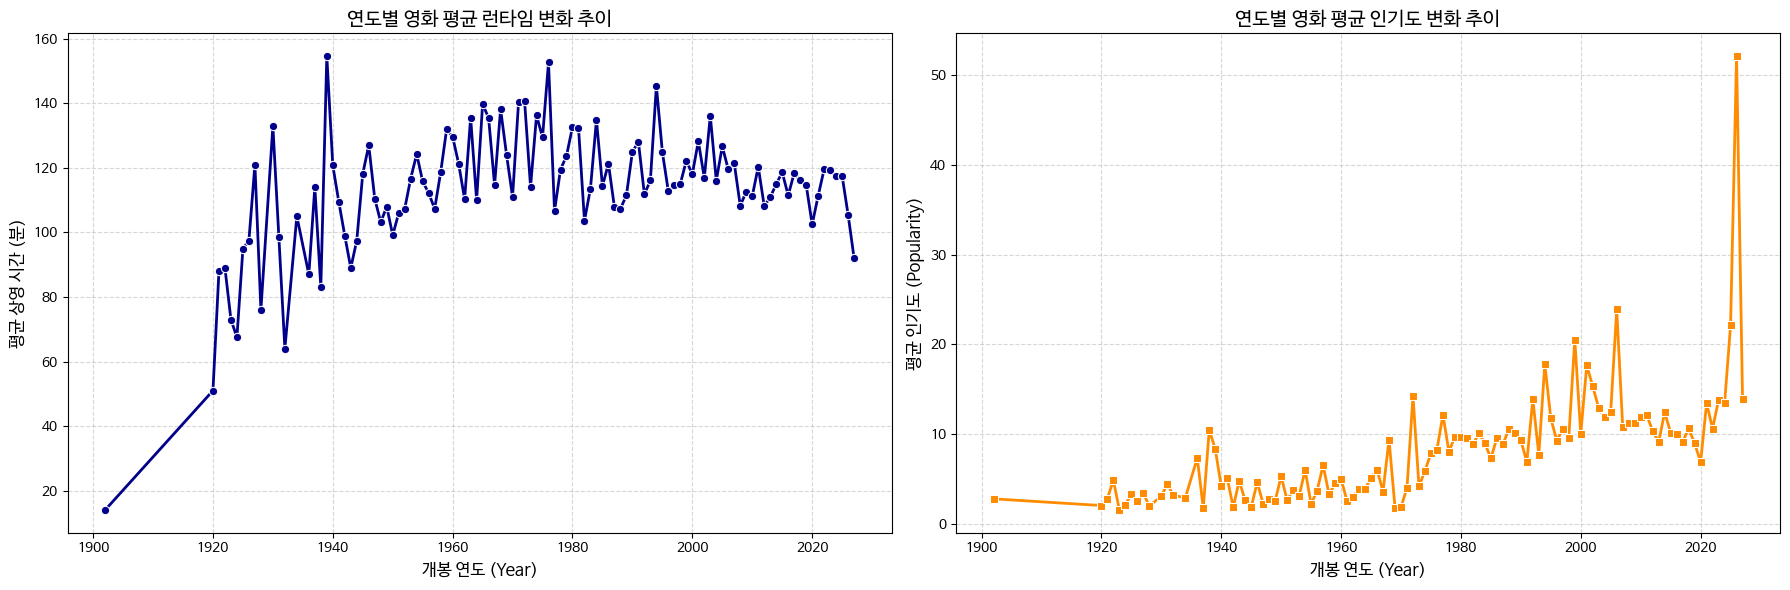

In [49]:
year_trend = movie_time.groupby('release_year')[['runtime', 'popularity']].mean().reset_index()

fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(18, 6))

sns.lineplot(
    data=year_trend,
    x='release_year',
    y='runtime',
    marker='o',
    color='darkblue',
    linewidth=2,
    ax=axes[0]
)
axes[0].set_title('연도별 영화 평균 런타임 변화 추이', fontsize=14, fontweight='bold')
axes[0].set_xlabel('개봉 연도 (Year)', fontsize=12)
axes[0].set_ylabel('평균 상영 시간 (분)', fontsize=12)
axes[0].grid(True, linestyle='--', alpha=0.5)

sns.lineplot(
    data=year_trend,
    x='release_year',
    y='popularity',
    marker='s',
    color='darkorange',
    linewidth=2,
    ax=axes[1]
)
axes[1].set_title('연도별 영화 평균 인기도 변화 추이', fontsize=14, fontweight='bold')
axes[1].set_xlabel('개봉 연도 (Year)', fontsize=12)
axes[1].set_ylabel('평균 인기도 (Popularity)', fontsize=12)
axes[1].grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

1900년대 말, 2000년대 초 영화들의 평균 런타임이 110분 ~ 140분

최근(2010년대 이후)의 점진적 감소 추세: 2000년대 들어서면서 그래프가 완만하게 우하향하기 시작하더니, 최근 2020년대에는 평균 런타임이 90분~100분대까지 확연하게 감소

즉 사용자들의 도파민 뇌에 따라 영화 시간도 감소한 것을 알 수 있음.

유튜브를 봐도 영화요약이 인기인 만큼 런타임이 긴 영화에 수요가 줄고 있음.


인기도 역시 상대적으로 최신 영화를 더 많이 검색하고 평점을 남기기 때문이다.

앞선 분석으로 vote_count가 낮다면, 그런 분석을 흐리는 경향이 있어

일정 vote_count 이상으로 분석을 진행함

### 2.2 영화의 트렌드 분석

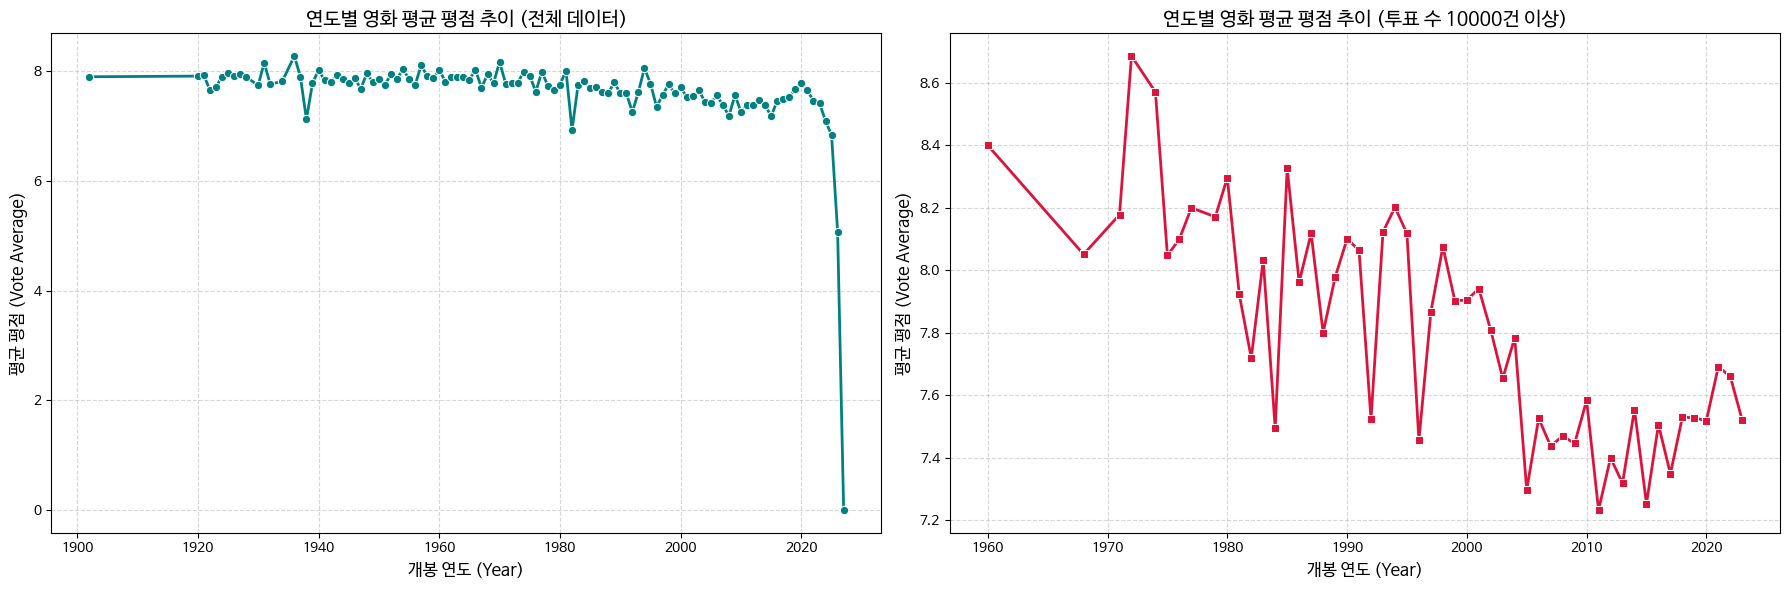

In [54]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. 데이터 준비 및 집계
# 1) 전체 영화 기준 연도별 평균 평점
trend_all = movie_time.groupby('release_year')['vote_average'].mean().reset_index()

# 2) 신뢰도를 위해 투표 수 100개 이상인 영화만 필터링한 기준
movie_filtered = movie_time[movie_time['vote_count'] >= 10000]
trend_filtered = movie_filtered.groupby('release_year')['vote_average'].mean().reset_index()

# 2. 시각화 시작 (1행 2열 도화지)
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(18, 6))

# [왼쪽 그래프] 전체 영화 기준 연도별 평균 평점
sns.lineplot(
    data=trend_all,
    x='release_year',
    y='vote_average',
    marker='o',
    color='teal',
    linewidth=2,
    ax=axes[0]
)
axes[0].set_title('연도별 영화 평균 평점 추이 (전체 데이터)', fontsize=14, fontweight='bold')
axes[0].set_xlabel('개봉 연도 (Year)', fontsize=12)
axes[0].set_ylabel('평균 평점 (Vote Average)', fontsize=12)
axes[0].grid(True, linestyle='--', alpha=0.5)

# [오른쪽 그래프] 투표 수 100건 이상 영화 기준 연도별 평균 평점
sns.lineplot(
    data=trend_filtered,
    x='release_year',
    y='vote_average',
    marker='s',
    color='crimson',
    linewidth=2,
    ax=axes[1]
)
axes[1].set_title('연도별 영화 평균 평점 추이 (투표 수 10000건 이상)', fontsize=14, fontweight='bold')
axes[1].set_xlabel('개봉 연도 (Year)', fontsize=12)
axes[1].set_ylabel('평균 평점 (Vote Average)', fontsize=12)
axes[1].grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

오히려 시간이 지날수록, 평점은 낮아지는 경향.

고전 명작의 법칙: 과거 영화들이 전반적으로 평점이 높은 이유는 "시간의 필터" 때문입니다. 수십 년이 지난 지금까지 TMDB에 등록되고 유저들이 찾아와 100번 이상 투표를 남길 정도의 과거 영화라면, 대부분 역사적으로 검증된 '명작'들만 살아남았기 때문(생존 편향, Survival Bias)에 평점이 높게 유지되는 것

"인기도는 최신작이 높지만, 평점은 오히려 과거 명작들이 높고 최신작일수록 혹독한 평가를 받는다."

### 2.3 계절성(Seasonality) 분석

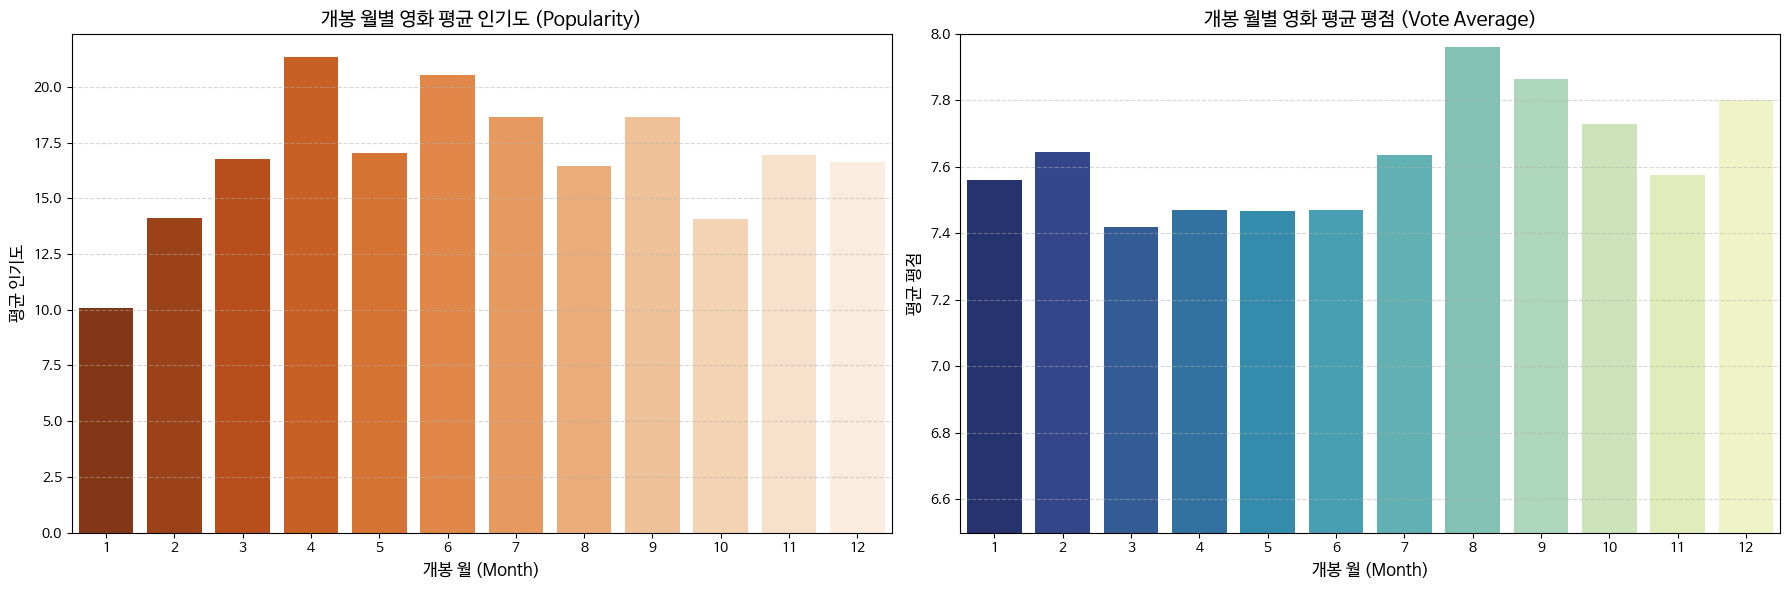

In [55]:
month_trend = movie_filtered.groupby('release_month')[['popularity', 'vote_average']].mean().reset_index()

# 2. 시각화 시작 (1행 2열)
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(18, 6))

# [왼쪽 그래프] 월별 평균 인기도 (대중의 관심도 시즌성)
sns.barplot(
    data=month_trend,
    x='release_month',
    y='popularity',
    palette='Oranges_r',
    ax=axes[0]
)
axes[0].set_title('개봉 월별 영화 평균 인기도 (Popularity)', fontsize=14, fontweight='bold')
axes[0].set_xlabel('개봉 월 (Month)', fontsize=12)
axes[0].set_ylabel('평균 인기도', fontsize=12)
axes[0].grid(True, axis='y', linestyle='--', alpha=0.5)

# [오른쪽 그래프] 월별 평균 평점 (작품성/만족도 시즌성)
sns.barplot(
    data=month_trend,
    x='release_month',
    y='vote_average',
    palette='YlGnBu_r',
    ax=axes[1]
)
# 변별력을 높이기 위해 y축 범위를 6.5점부터 설정합니다.
axes[1].set_ylim(6.5, 8.0)
axes[1].set_title('개봉 월별 영화 평균 평점 (Vote Average)', fontsize=14, fontweight='bold')
axes[1].set_xlabel('개봉 월 (Month)', fontsize=12)
axes[1].set_ylabel('평균 평점', fontsize=12)
axes[1].grid(True, axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

결과

4,6월이 평균 인기도는 높아서, 관객들이 많이봄 = 트렌드성 영화

8~9월은 스토리가 탄탄한 완성도의 영화라고 이름 지을 수 있을 것이다.

마블 시네마틱 유니버스(MCU)를 비롯한 글로벌 초대형 텐트폴(블록버스터) 영화들이 전 세계 극장가를 선점하기 위해 4월 말이나 6월에 집중적으로 개봉

8월 말이나 9월 스토리가 탄탄한 웰메이드 한국 영화 대작들이나 작품성 높은 외화, 시네필들이 환호하는 영화

## **3. 범주형 및 텍스트 데이터 탐색**

### 3.1 장르(genres) 분석

In [56]:
movie_genres = movie_filtered.copy()
movie_genres['genres_list'] = movie_genres['genres'].apply(lambda x: [g.strip() for g in str(x).split(',')] if pd.notna(x) else [])

# explode 함수를 사용해 리스트의 각 원소를 개별 행으로 펼치기
movie_exploded = movie_genres.explode('genres_list')

# 혹시 장르명이 비어있거나 무의미한 데이터가 있다면 제거
movie_exploded = movie_exploded[movie_exploded['genres_list'] != '']

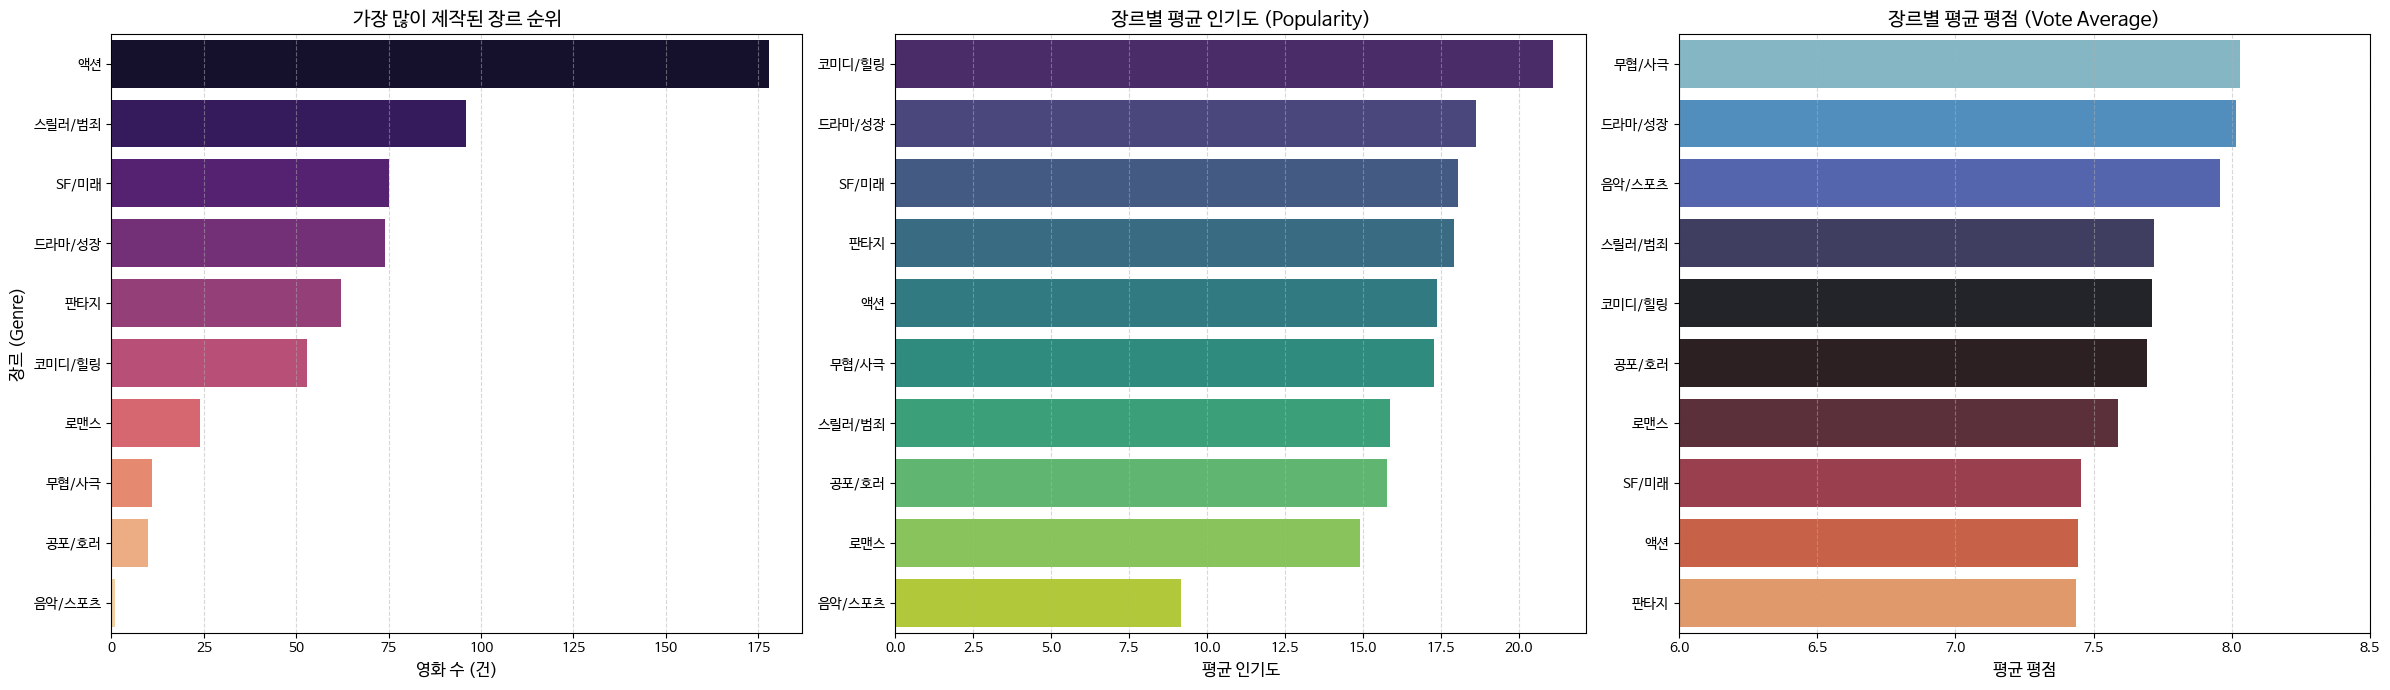

In [57]:
movie_genres = movie_filtered.copy()
movie_genres['genres_list'] = movie_genres['genres'].apply(lambda x: [g.strip() for g in str(x).split(',')] if pd.notna(x) else [])

# explode 함수를 사용해 리스트의 각 원소를 개별 행으로 펼치기
movie_exploded = movie_genres.explode('genres_list')

# 혹시 장르명이 비어있거나 무의미한 데이터가 있다면 제거
movie_exploded = movie_exploded[movie_exploded['genres_list'] != '']

# 2. 장르별 데이터 집계
# 장르별 영화 빈도수(제작 건수), 평균 인기도, 평균 평점 계산
genre_stats = movie_exploded.groupby('genres_list').agg(
    movie_count=('title', 'count'),
    mean_popularity=('popularity', 'mean'),
    mean_vote=('vote_average', 'mean')
).reset_index()

# 가장 많이 제작된 장르 순으로 정렬
genre_stats = genre_stats.sort_values(by='movie_count', ascending=False)

# 3. 시각화 시작 (1행 3열 도화지 구성)
fig, axes = plt.subplots(nrows=1, ncols=3, figsize=(24, 7))

# [왼쪽 그래프] 가장 많이 제작된 장르 순위 (제작 건수)
sns.barplot(
    data=genre_stats,
    y='genres_list',
    x='movie_count',
    palette='magma',
    ax=axes[0]
)
axes[0].set_title('가장 많이 제작된 장르 순위', fontsize=14, fontweight='bold')
axes[0].set_xlabel('영화 수 (건)', fontsize=12)
axes[0].set_ylabel('장르 (Genre)', fontsize=12)
axes[0].grid(True, axis='x', linestyle='--', alpha=0.5)

# [중앙 그래프] 장르별 평균 인기도 (대중성)
# 보기 편하게 인기도 순으로 정렬해서 시각화
genre_pop_sorted = genre_stats.sort_values(by='mean_popularity', ascending=False)
sns.barplot(
    data=genre_pop_sorted,
    y='genres_list',
    x='mean_popularity',
    palette='viridis',
    ax=axes[1]
)
axes[1].set_title('장르별 평균 인기도 (Popularity)', fontsize=14, fontweight='bold')
axes[1].set_xlabel('평균 인기도', fontsize=12)
axes[1].set_ylabel('', fontsize=12) # y축 라벨 생략
axes[1].grid(True, axis='x', linestyle='--', alpha=0.5)

# [오른쪽 그래프] 장르별 평균 평점 (만족도)
# 평점 순으로 정렬하고, 변별력을 위해 x축 범위를 6.0 ~ 8.5로 설정
genre_vote_sorted = genre_stats.sort_values(by='mean_vote', ascending=False)
sns.barplot(
    data=genre_vote_sorted,
    y='genres_list',
    x='mean_vote',
    palette='icefire',
    ax=axes[2]
)
axes[2].set_xlim(6.0, 8.5)
axes[2].set_title('장르별 평균 평점 (Vote Average)', fontsize=14, fontweight='bold')
axes[2].set_xlabel('평균 평점', fontsize=12)
axes[2].set_ylabel('', fontsize=12) # y축 라벨 생략
axes[2].grid(True, axis='x', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

인기도 1위: 제작 건수로는 중간 순위(6위, 약 50여 건)에 불과했던 '코미디/힐링' 장르가 평균 인기도에서는 당당히 1위

평점 1위의 위엄: 제작 건수에서는 하위권(8위, 단 10여 건)에 머물렀던 '무협/사극' 장르가 평균 평점에서는 약 8.0점으로 압도적 1위

많이 만들어지는 장르: 액션, 스릴러/범죄 (흥행 안전빵)

대중이 가장 많이 찾는 장르: 코미디/힐링 (높은 트래픽)

진짜 웰메이드가 많은 장르: 무협/사극, 드라마/성장 (높은 충성도)

### 3.2 핵심 인물 분석

In [58]:
movie_people = movie_filtered.copy()

# ====================================================
# [1] 감독(Director) 분석
# ====================================================
# 감독별 작품 수, 평균 인기도, 평균 평점 집계
director_stats = movie_people.groupby('director').agg(
    movie_count=('title', 'count'),
    mean_popularity=('popularity', 'mean'),
    mean_vote=('vote_average', 'mean')
).reset_index()

# 다작 감독 상위 5명
top_pro_directors = director_stats.sort_values(by='movie_count', ascending=False).head(5)

# 믿고 보는 감독 상위 5명 (최소 3편 이상 연출한 감독 중 평점 기준)
trusted_directors = director_stats[director_stats['movie_count'] >= 3].sort_values(by='mean_vote', ascending=False).head(5)


# ====================================================
# [2] 배우(Cast) 분석
# ====================================================
# cast 컬럼을 리스트로 변환 후 분리(Explode)
movie_people['cast_list'] = movie_people['cast'].apply(lambda x: [c.strip() for c in str(x).split(',')] if pd.notna(x) else [])
cast_exploded = movie_people.explode('cast_list')
cast_exploded = cast_exploded[cast_exploded['cast_list'] != ''] # 빈 값 제거

# 배우별 작품 수, 평균 인기도, 평균 평점 집계
cast_stats = cast_exploded.groupby('cast_list').agg(
    movie_count=('title', 'count'),
    mean_popularity=('popularity', 'mean'),
    mean_vote=('vote_average', 'mean')
).reset_index()

# 다작 배우 상위 5명
top_pro_actors = cast_stats.sort_values(by='movie_count', ascending=False).head(5)

# 믿고 보는 배우 상위 5명 (최소 3편 이상 출연한 배우 중 평점 기준)
trusted_actors = cast_stats[cast_stats['movie_count'] >= 3].sort_values(by='mean_vote', ascending=False).head(5)


# ====================================================
# [3] 결과 출력
# ====================================================
print("🎬 [감독 분석 결과]")
print("-" * 50)
print("🔥 가장 많은 작품을 찍은 다작 감독 상위 5:")
print(top_pro_directors[['director', 'movie_count']].to_string(index=False))
print("\n⭐ 평점이 높은 '믿고 보는' 감독 상위 5 (최소 3편 이상):")
print(trusted_directors[['director', 'movie_count', 'mean_vote']].to_string(index=False))

print("\n" + "="*50 + "\n")

print("🎭 [배우 분석 결과]")
print("-" * 50)
print("🔥 가장 많은 작품을 찍은 다작 배우 상위 5:")
print(top_pro_actors[['cast_list', 'movie_count']].to_string(index=False))
print("\n⭐ 평점이 높은 '믿고 보는' 배우 상위 5 (최소 3편 이상):")
print(trusted_actors[['cast_list', 'movie_count', 'mean_vote']].to_string(index=False))

🎬 [감독 분석 결과]
--------------------------------------------------
🔥 가장 많은 작품을 찍은 다작 감독 상위 5:
director  movie_count
크리스토퍼 놀란           10
스티븐 스필버그           10
쿠엔틴 타란티노            8
 제임스 카메론            6
   피터 잭슨            6

⭐ 평점이 높은 '믿고 보는' 감독 상위 5 (최소 3편 이상):
director  movie_count  mean_vote
 마틴 스콜세지            5   8.197800
 스탠리 큐브릭            4   8.136750
로버트 저메키스            4   8.068000
  리들리 스콧            4   8.008250
쿠엔틴 타란티노            8   8.004125


🎭 [배우 분석 결과]
--------------------------------------------------
🔥 가장 많은 작품을 찍은 다작 배우 상위 5:
  cast_list  movie_count
      톰 행크스           10
      엠마 왓슨           10
       조니 뎁            9
로버트 다우니 주니어            9
레오나르도 디카프리오            9

⭐ 평점이 높은 '믿고 보는' 배우 상위 5 (최소 3편 이상):
cast_list  movie_count  mean_vote
    알 파치노            3   8.471333
  일라이저 우드            3   8.450000
   비고 모텐슨            4   8.393500
    잭 니콜슨            3   8.258000
 로버트 드 니로            3   8.241667


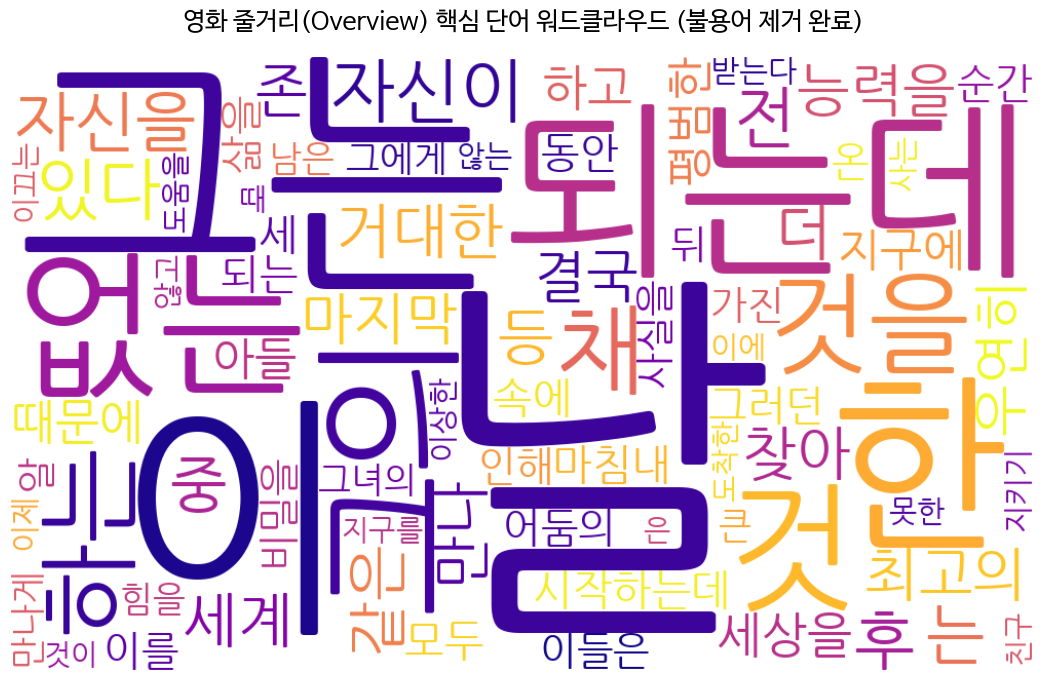

In [63]:
from wordcloud import WordCloud, STOPWORDS
import platform

# 1. 운영체제별 한글 폰트 경로 자동 설정
if platform.system() == 'Windows':
    font_path = "c:/Windows/Fonts/malgun.ttf"
elif platform.system() == 'Darwin':
    font_path = "/System/Library/Fonts/Supplemental/AppleGothic.ttf"
else:
    font_path = "/usr/share/fonts/truetype/nanum/NanumGothic.ttf"

# 2. 텍스트 데이터 통합
all_overviews = " ".join(movie_filtered['overview'].dropna().astype(str))

# 3. 🔥 불용어 세트 대폭 강화
custom_stopwords = set(STOPWORDS)
korean_stopwords = [
    # 유저가 요청한 제거 단어
    '하지만',
    '한편', '그를', '그러나', '점점', '그', '된다', '된', '있는', '한다', '어느',
    '바로', '두', '사람은', '의해', '수', '그리고', '있던', '모든', '사람', '사람들은',
    # 줄거리에 무조건 등장하는 기본 서술어 및 지시어
    '영화', '영화는', '그들의', '그녀는', '시작한다', '위해', '함께', '자신의',
    '그가', '사건을', '대한', '속에서', '다시', '새로운', '위한', '가운데', '가장',
    '어떤', '통해', '가지고', '알게', '되고', '위해', '그것을', '서로', '앞에', '가며',
    '하게', '않은', '과연', '없이', '속으로', '하나의', '할', '있어', '하며', '다른'
]
custom_stopwords.update(korean_stopwords)

# 4. 워드클라우드 객체 생성
wordcloud = WordCloud(
    font_path=font_path,
    width=1000,
    height=600,
    background_color='white',
    stopwords=custom_stopwords,  # 필터링 적용
    max_words=80,                # 핵심 단어만 집중해서 보기 위해 80개로 조정
    colormap='plasma',           # 가독성이 좋은 선명한 테마로 변경
    random_state=42
).generate(all_overviews)

# 5. 시각화 출력
plt.figure(figsize=(15, 8))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('영화 줄거리(Overview) 핵심 단어 워드클라우드 (불용어 제거 완료)', fontsize=18, fontweight='bold', pad=20)
plt.show()

불용어를 엄청 많이 제거 해도 나와서 이 분석은 여기까지.

## **5. 변수 간 상관관계 분석 (Correlation Analysis)**

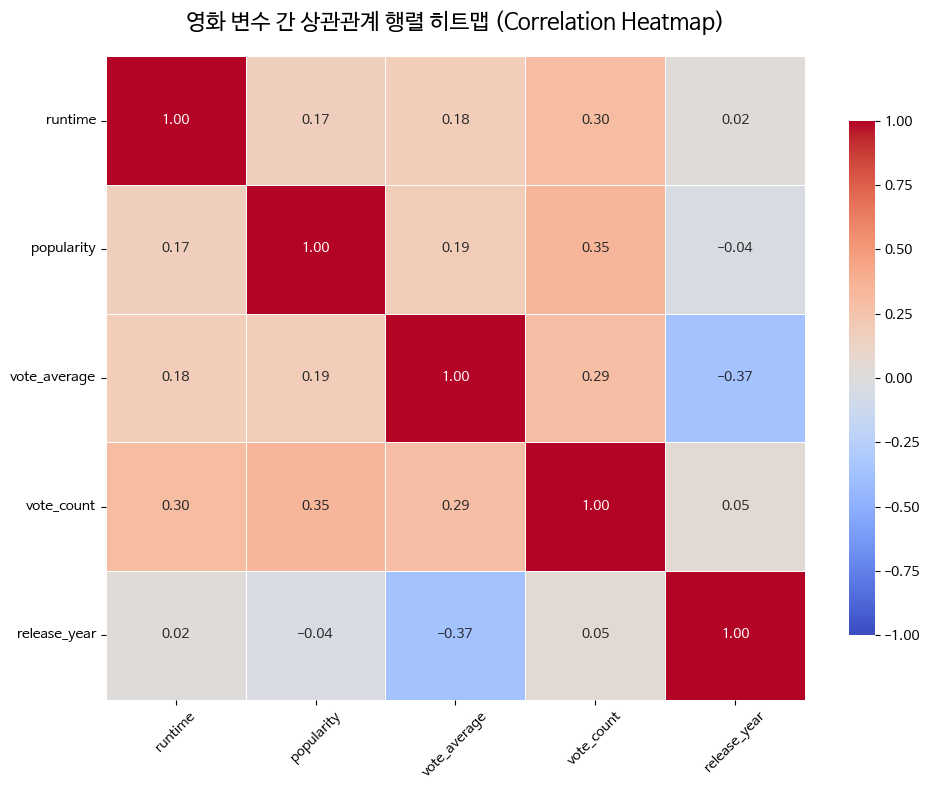

In [64]:
# 1. 상관관계 분석에 사용할 수치형 변수들만 선택
# 기존에 생성해 둔 'release_year' 컬럼이 포함되어 있는지 확인해 주세요.
features = ['runtime', 'popularity', 'vote_average', 'vote_count', 'release_year']
correlation_matrix = movie_filtered[features].corr()

# 2. 시각화 시작
plt.figure(figsize=(10, 8))

# 히트맵 그리기
# annot=True: 네모 칸 안에 실제 상관계수 숫자 표시
# cmap='coolwarm': 양의 상관관계는 빨간색, 음의 상관관계는 파란색으로 직관적 표시
# vmin=-1, vmax=1: 상관계수 범위를 -1부터 1로 고정
sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap='coolwarm',
    vmin=-1,
    vmax=1,
    linewidths=0.5,
    cbar_kws={"shrink": .8}
)

plt.title('영화 변수 간 상관관계 행렬 히트맵 (Correlation Heatmap)', fontsize=16, fontweight='bold', pad=20)
plt.xticks(rotation=45) # x축 라벨 각도 조절로 가독성 확보
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

앞선 분석에서 vote_count가 결과를 흐리게 만드는 경향이 있는 것 같아서
vote_count가 1만 이상으로 다시 코드를 작성

🔥 초고흥행작(투표 수 15,000건 이상) 영화 수: 152편


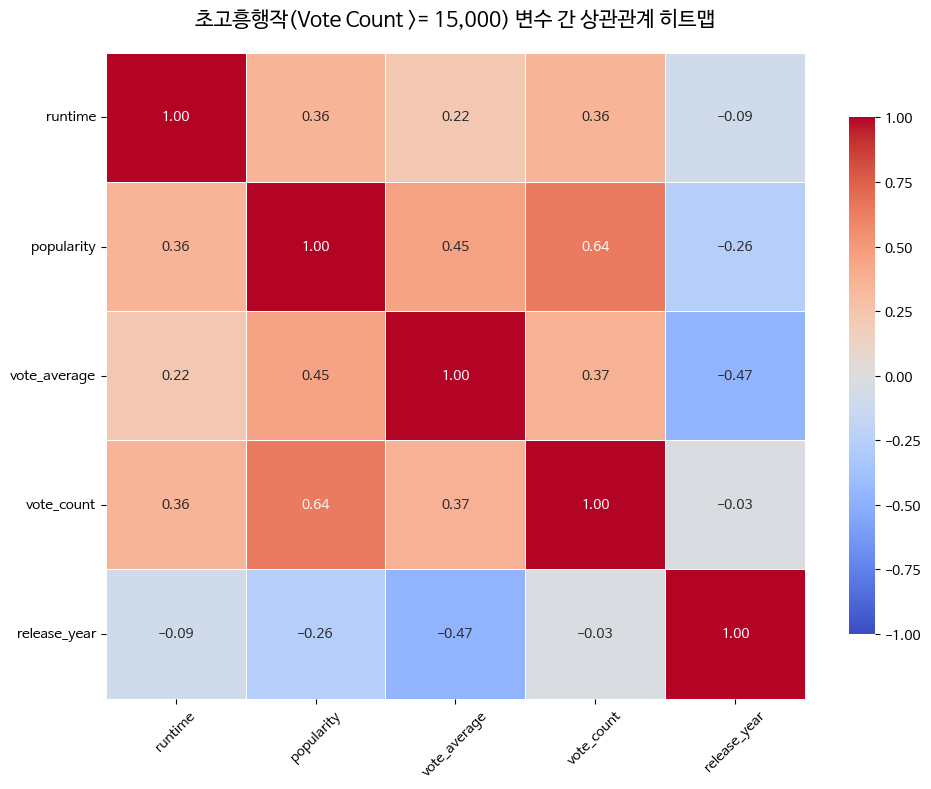

In [66]:
# 1. 투표 수(vote_count) 15,000건 이상 초고흥행작들만 필터링
movie_mega_hit = movie_time[movie_time['vote_count'] >= 15000]

# 필터링 후 남은 영화 개수 확인
print(f"🔥 초고흥행작(투표 수 15,000건 이상) 영화 수: {len(movie_mega_hit)}편")

# 2. 상관관계 분석에 사용할 수치형 변수들 선택
features = ['runtime', 'popularity', 'vote_average', 'vote_count', 'release_year']
correlation_matrix_mega = movie_mega_hit[features].corr()

# 3. 시각화 시작
plt.figure(figsize=(10, 8))

sns.heatmap(
    correlation_matrix_mega,
    annot=True,
    fmt=".2f",
    cmap='coolwarm',
    vmin=-1,
    vmax=1,
    linewidths=0.5,
    cbar_kws={"shrink": .8}
)

plt.title('초고흥행작(Vote Count >= 15,000) 변수 간 상관관계 히트맵', fontsize=15, fontweight='bold', pad=20)
plt.xticks(rotation=45)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

앞선 분석에서 확인했듯이 vote_count와 인기도는 양의 상관관계,

평점과 년도는 음의 상관 관계를 가지는 것을 알 수 있다.

🎬 1970년 이후 현대 초고흥행작 영화 수: 305편


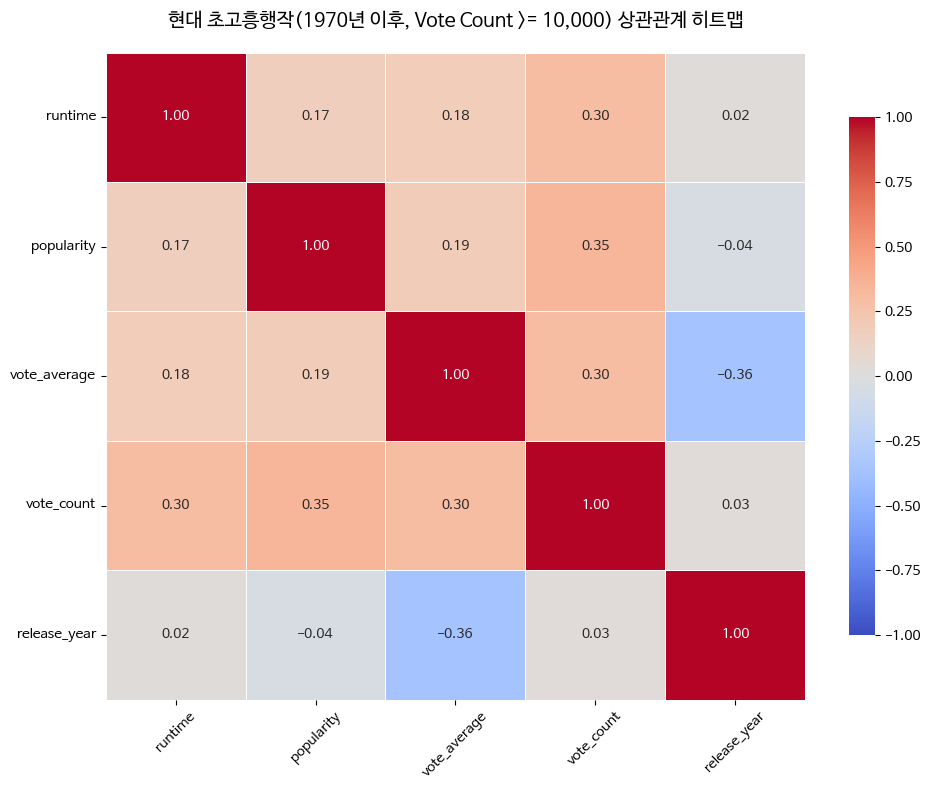

In [67]:
# 1. 1970년 이후 & 투표 수 10,000건 이상인 데이터만 이중 필터링
movie_modern_mega = movie_time[
    (movie_time['release_year'] >= 1970) &
    (movie_time['vote_count'] >= 10000)
]

# 필터링 후 최종 생존한 영화 편수 확인
print(f"🎬 1970년 이후 현대 초고흥행작 영화 수: {len(movie_modern_mega)}편")

# 2. 수치형 변수 선택 및 상관계수 계산
features = ['runtime', 'popularity', 'vote_average', 'vote_count', 'release_year']
correlation_matrix_modern = movie_modern_mega[features].corr()

# 3. 히트맵 시각화
plt.figure(figsize=(10, 8))

sns.heatmap(
    correlation_matrix_modern,
    annot=True,
    fmt=".2f",
    cmap='coolwarm',
    vmin=-1,
    vmax=1,
    linewidths=0.5,
    cbar_kws={"shrink": .8}
)

plt.title('현대 초고흥행작(1970년 이후, Vote Count >= 10,000) 상관관계 히트맵', fontsize=14, fontweight='bold', pad=20)
plt.xticks(rotation=45)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()